In [35]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras import Input
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [22]:
train = pd.read_csv(r"C:\Users\flori\OneDrive\Desktop\Python\Visual Code\Zooms\DeepLearning\train_black_friday.csv")
test = pd.read_csv(r"C:\Users\flori\OneDrive\Desktop\Python\Visual Code\Zooms\DeepLearning\test_black_friday.csv")
print(train["Product_ID"])

0         P00069042
1         P00248942
2         P00087842
3         P00085442
4         P00285442
            ...    
550063    P00372445
550064    P00375436
550065    P00375436
550066    P00375436
550067    P00371644
Name: Product_ID, Length: 550068, dtype: str


In [23]:
train["Product_ID"] = train["Product_ID"].astype("category").cat.codes
test["Product_ID"] = test["Product_ID"].astype("category").cat.codes
print(train["Product_ID"])

0          672
1         2376
2          852
3          828
4         2734
          ... 
550063    3567
550064    3568
550065    3568
550066    3568
550067    3566
Name: Product_ID, Length: 550068, dtype: int16


In [24]:
train["Type"] = "Train"
test["Type"] = "Test"
fullData = pd.concat([train,test], axis=0)

In [25]:
id_col = ["User_ID","Product_ID"]
flag_col = ["Type"]
target_col = ["Purchase"]
cat_cols = ["Gender","Age","City_Category","Stay_In_Current_City_Years"]
num_cols = list(
    set(fullData.columns)
    - set(cat_cols)
    - set(id_col)
    - set(target_col)
    - set(flag_col)
)

In [26]:
for var in cat_cols + num_cols:
    if fullData[var].isnull().any():
        fullData[var + "_NA"] = fullData[var].isnull() * 1

fullData[num_cols] = fullData[num_cols].fillna(fullData[num_cols].mean())
fullData[cat_cols] = fullData[cat_cols].fillna(-9999)


In [27]:
for var in cat_cols:
    le = LabelEncoder()
    fullData[var] = le.fit_transform(fullData[var].astype("str"))

features = list(
    set(fullData.columns)
    - set(id_col)
    - set(target_col)
    - set(flag_col)
)
fullData[features] = fullData[features] / fullData[features].max()

In [30]:
train_data = fullData[fullData["Type"] == "Train"]
test_data = fullData[fullData["Type"] == "Test"]

scaler = StandardScaler()
x = scaler.fit_transform(train_data[features].values)

y = train_data[target_col].values

x_train, x_valid, y_train, y_valid = train_test_split(x,y,test_size=0.3,random_state=42)

In [31]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(x_train,y_train.ravel())

rf_preds = rf.predict(x_valid)

rf_rmse = np.sqrt(mean_squared_error(y_valid, rf_preds))
print(f"Random Forest RSME: {rf_rmse}")

Random Forest RSME: 3063.3979944714415


In [32]:
model = Sequential([
    Input(shape=(len(features),)),
    Dense(200, activation="relu", kernel_regularizer=l2(0.01)),
    Dropout(0.3),
    Dense(100, activation="relu", kernel_regularizer=l2(0.01)),
    Dropout(0.3),
    Dense(50, activation="relu"),
    Dense(1)
])

model.compile(loss="mean_squared_error", optimizer=Adam(learning_rate=0.001), metrics=["mean_squared_error"])

In [33]:
early_stopping = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

history = model.fit(x_train, y_train,
                    epochs=10,
                    validation_data=(x_valid, y_valid),
                    callbacks=[early_stopping],
                    verbose=1)

Epoch 1/10
12033/12033 ━━━━━━━━━━━━━━━━━━━━ 16s 1ms/step - loss: 20444466.0000 - mean_squared_error: 20444452.0000 - val_loss: 17850338.0000 - val_mean_squared_error: 17850314.0000
Epoch 2/10
12033/12033 ━━━━━━━━━━━━━━━━━━━━ 15s 1ms/step - loss: 18260296.0000 - mean_squared_error: 18260280.0000 - val_loss: 16528198.0000 - val_mean_squared_error: 16528171.0000
Epoch 3/10
12033/12033 ━━━━━━━━━━━━━━━━━━━━ 16s 1ms/step - loss: 16904090.0000 - mean_squared_error: 16904064.0000 - val_loss: 15174355.0000 - val_mean_squared_error: 15174325.0000
Epoch 4/10
12033/12033 ━━━━━━━━━━━━━━━━━━━━ 16s 1ms/step - loss: 16238382.0000 - mean_squared_error: 16238353.0000 - val_loss: 14652507.0000 - val_mean_squared_error: 14652471.0000
Epoch 5/10
12033/12033 ━━━━━━━━━━━━━━━━━━━━ 16s 1ms/step - loss: 15917235.0000 - mean_squared_error: 15917203.0000 - val_loss: 14345995.0000 - val_mean_squared_error: 14345957.0000
Epoch 6/10
12033/12033 ━━━━━━━━━━━━━━━━━━━━ 16s 1ms/step - loss: 15777525.0000 - mean_squared_e

In [34]:
nn_preds = model.predict(x_valid)
nn_rmse = np.sqrt(mean_squared_error(y_valid, nn_preds))
print(f"Neural Network RMSE: {nn_rmse}")

final_preds = (rf_preds + nn_preds.flatten()) / 2
ensemble_rmse = np.sqrt(mean_squared_error(y_valid, final_preds))
print(f"Ensemble RMSE: {ensemble_rmse}")

5157/5157 ━━━━━━━━━━━━━━━━━━━━ 2s 462us/step
Neural Network RMSE: 3751.465857559597
Ensemble RMSE: 3137.4976858848004


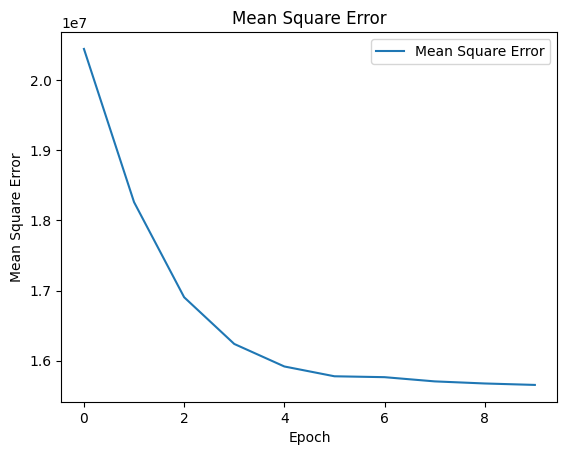

In [39]:
plt.plot(history.history["mean_squared_error"],label="Mean Square Error")
plt.title("Mean Square Error")
plt.xlabel("Epoch")
plt.ylabel("Mean Square Error")
plt.legend()
plt.show()